# Prática — Módulo 9: Árvores em Análise Preditiva

In [1]:
# Importações
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Carregar dataset
df = pd.read_csv("/content/renda-emprestimo-risco.csv", sep = ";")
df

,index,idade,renda_anual,tempo_emprego,estado_civil,valor_solicitado,risco
0,0,56,36453.68,3,solteiro,21452.64,alto
1,1,46,67929.83,15,casado,33282.52,alto
2,2,32,68234.96,6,solteiro,34204.77,alto
3,3,25,68049.49,12,solteiro,39411.72,alto
4,4,38,35318.77,9,casado,16724.26,alto
...,...,...,...,...,...,...,...
195,195,23,63339.27,19,casado,29406.02,alto
196,196,49,24000.00,4,solteiro,9717.64,medio
197,197,21,41566.46,1,casado,19295.04,alto
198,198,28,65350.89,5,casado,29559.83,medio


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             200 non-null    int64  
 1   idade             200 non-null    int64  
 2   renda_anual       200 non-null    float64
 3   tempo_emprego     200 non-null    int64  
 4   estado_civil      200 non-null    object 
 5   valor_solicitado  200 non-null    float64
 6   risco             200 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 11.1+ KB


In [4]:
df = df.drop(columns=["index"])

## Pergunta
1. Qual é a variável alvo se o problema for de classificação?
2. Alguma variável categórica precisa ser tratada OBRIGATORIAMENTE? Qual/is?

In [5]:
# Codificando única variável categórica
df["estado_civil"] = df["estado_civil"].map({
    "solteiro": 0,
    "casado": 1
})

df

,idade,renda_anual,tempo_emprego,estado_civil,valor_solicitado,risco
0,56,36453.68,3,0,21452.64,alto
1,46,67929.83,15,1,33282.52,alto
2,32,68234.96,6,0,34204.77,alto
3,25,68049.49,12,0,39411.72,alto
4,38,35318.77,9,1,16724.26,alto
...,...,...,...,...,...,...
195,23,63339.27,19,1,29406.02,alto
196,49,24000.00,4,0,9717.64,medio
197,21,41566.46,1,1,19295.04,alto
198,28,65350.89,5,1,29559.83,medio


In [6]:
df.describe()

,idade,renda_anual,tempo_emprego,estado_civil,valor_solicitado
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,38.665000,50644.286550,9.175000,0.490000,19842.384600
std,12.604648,14006.058244,5.848538,0.501154,7835.562524
min,18.000000,24000.000000,0.000000,0.000000,5310.920000
25%,27.750000,40576.497500,4.000000,0.000000,14125.277500
50%,40.000000,49833.450000,9.000000,0.000000,18436.455000
75%,49.250000,61321.517500,14.000000,1.000000,25829.330000
max,59.000000,87375.680000,19.000000,1.000000,41335.440000


# Pergunta
3. Os dados parecem seguir relações lineares entre as variáveis ou apresentam padrões não lineares? O que isso implica na escolha do modelo?
4. Se duas variáveis apresentam relação linear (correlação), isso garante que as classes são linearmente separáveis?

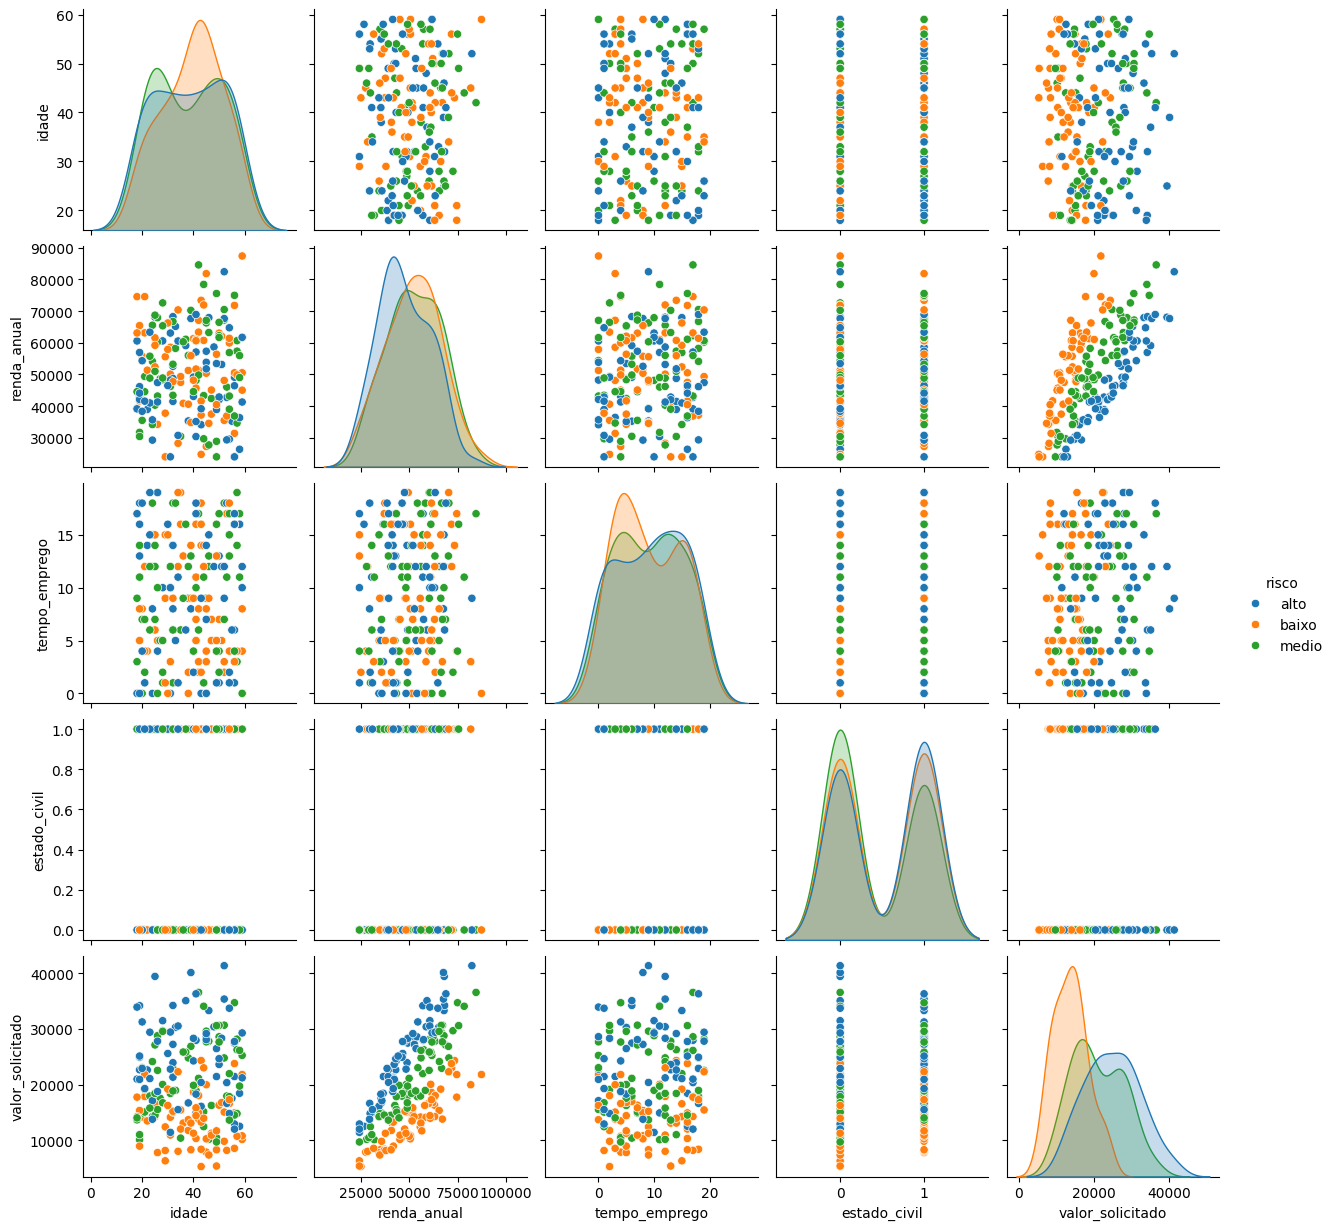

In [7]:
# Analisando correlação e separabilidade linear
sns.pairplot(df, hue="risco")
plt.show()

## Pergunta
5. Entre os modelos estudados (regressão linear, regressão logística, KNN e árvore de decisão), qual é mais adequado para esse problema e por quê?

In [8]:
from sklearn.model_selection import train_test_split

# Separando as variáveis explicativas e a variável alvo
X = df[["idade", "renda_anual", "tempo_emprego", "estado_civil", "valor_solicitado"]]
y = df["risco"]

# Separando dados de treino e de teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Pergunta
6. As variáveis explicativas (features) estão em escalas diferentes. Isso impacta o desempenho de uma árvore de decisão? Por quê?

7. Se aplicarmos escalonamento (ex: MinMax ou StandardScaler), o resultado da árvore muda? Por quê?

# Problema de Classificação

In [9]:
# Treinando uma árvore de decisão com parâmetros default
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

DecisionTreeClassifier()

In [10]:
y_pred = modelo.predict(X_test)

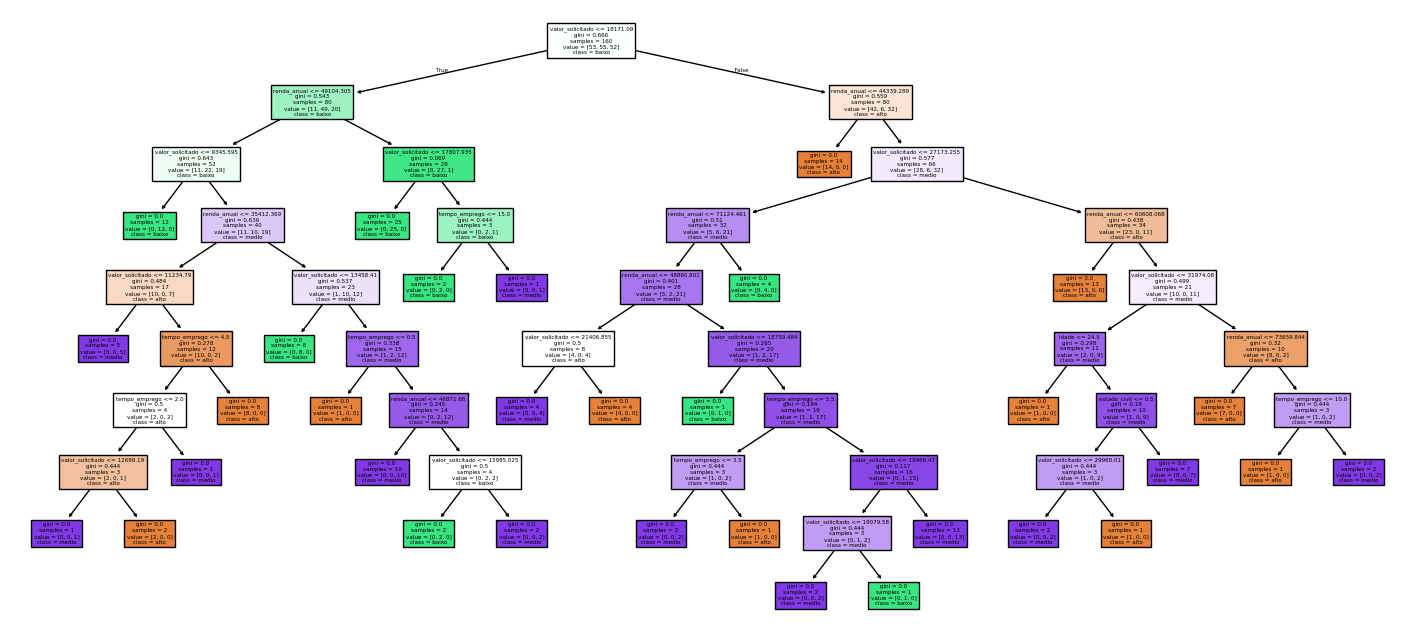

In [11]:
# Visualizando a árvore
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,8))
plot_tree(modelo, feature_names=X.columns, class_names=modelo.classes_, filled=True)
plt.show()

In [12]:
# Treinando uma árvore de decisão com parâmetros alterados
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion="gini",
    random_state=42
)

modelo.fit(X_train, y_train)
modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [13]:
y_pred = modelo.predict(X_test)

## Pergunta
9. Como se avalia erro em modelos de classificação?

In [14]:
# Avaliando o erro do modelo
from sklearn.metrics import precision_score, recall_score, f1_score

print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred, average="macro"))
print("recall:", recall_score(y_test, y_pred, average="macro"))
print("f1:", f1_score(y_test, y_pred, average="macro"))

accuracy: 0.8
precision: 0.8015873015873015
recall: 0.8015873015873015
f1: 0.8015873015873015


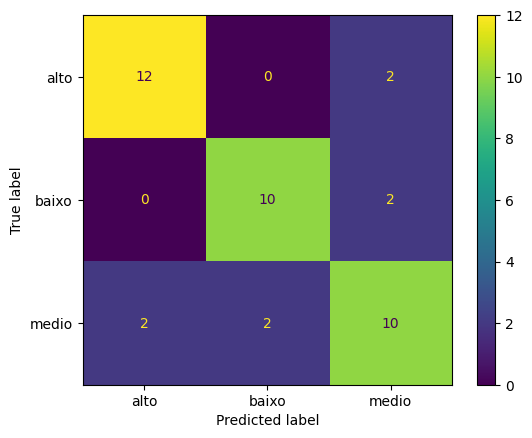

In [15]:
# Vendo a matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)
plt.show()

# Problema de Regressão

## Pergunta
8. Como eu transformaria este problema em um problema de regressão?

In [16]:
from sklearn.model_selection import train_test_split

# Separando as variáveis explicativas e a variável alvo
X = df[["idade", "renda_anual", "tempo_emprego", "estado_civil"]]
y = df["valor_solicitado"]

#  Separando dados de treino e de teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Treinando uma árvore de decisão com parâmetros default
from sklearn.tree import DecisionTreeRegressor

modelo = DecisionTreeRegressor()
modelo.fit(X_train, y_train)

DecisionTreeRegressor()

## Pergunta
10. Como se avalia erro em modelos de regressão?
11. Com base nas métricas de erro e na comparação entre valores reais e previstos, o modelo está realizando previsões precisas ou apresenta erros significativos? Justifique utilizando as evidências observadas.

In [18]:
# Avaliando o erro do modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = modelo.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 7274.411999999999
RMSE: 9381.30422882714
R2: -0.7346003047339238


In [19]:
df_res = pd.DataFrame({
    "real": y_test.values,
    "previsto": y_pred
})

df_res["erro"] = df_res["real"] - df_res["previsto"]

df_res

,real,previsto,erro
0,10817.02,15843.08,-5026.06
1,8323.84,16724.26,-8400.42
2,22932.81,27226.28,-4293.47
3,20994.60,22631.64,-1637.04
4,25243.33,30627.42,-5384.09
5,16616.26,33706.08,-17089.82
6,24259.01,10344.76,13914.25
7,29270.79,17301.82,11968.97
8,21446.23,11275.56,10170.67
9,29593.89,16316.35,13277.54


12. A diferença de desempenho da árvore entre classificação (melhor) e a regressão (pior) se deve ao modelo ou aos dados? Justifique.

In [20]:
# Visualizar informação mútua com relação a variável alvo
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)

mi_series = pd.Series(mi, index=X.columns, name="MI → valor_solicitado")
mi_series.sort_values(ascending=False)

,MI → valor_solicitado
renda_anual,0.453408
idade,0.058439
tempo_emprego,0.020938
estado_civil,0.020263


In [21]:
# Visualizar correlação com relação a variável alvo
corr_series = df.corr(numeric_only=True)["valor_solicitado"]
corr_series = corr_series.rename("Correlação → valor_solicitado")
corr_series.sort_values(ascending=False)

,Correlação → valor_solicitado
valor_solicitado,1.000000
renda_anual,0.662887
tempo_emprego,0.097694
estado_civil,0.037376
idade,0.017401


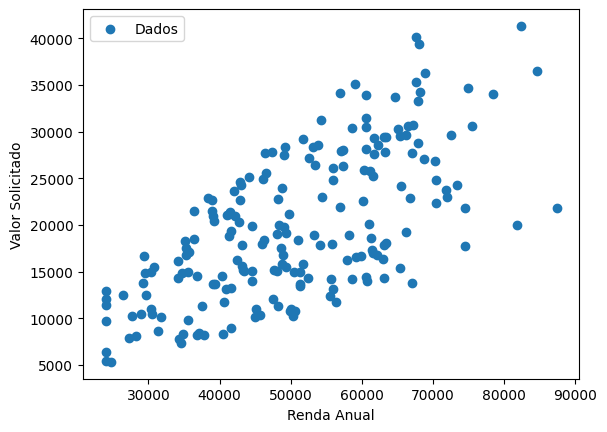

In [22]:
# Visualizando a dispersão entre a renda anual e o valor solicitado pelo cliente
import matplotlib.pyplot as plt

plt.scatter(df["renda_anual"], df["valor_solicitado"], label="Dados")
plt.xlabel("Renda Anual")
plt.ylabel("Valor Solicitado")
plt.legend()
plt.show()